In [3]:
import numpy as np

def find_hazard_rate(survival_rate):
    hazard_rates = []
    for i in range(len(survival_rate)):
        if i == 0:
            hazard_rates.append(1 - survival_rate[i])
        else:
            hazard_rates.append(1 - survival_rate[i] / survival_rate[i-1])
    return hazard_rates




def find_survival_rate_mise_weibull(survival_rates, lambd, beta):
    squared_error = []
    for i in range(len(survival_rates)):
        t = i+1
        estimated_survival_rate = np.exp(-lambd * (t ** beta))
        squared_error.append((estimated_survival_rate - survival_rates[i]) ** 2)
    
    return np.mean(squared_error)

def find_hazard_rate_mise_weibull(survival_rates, lambd, beta):
    # calculate ground truth hazard rate
    hazard_rates = []
    for i in range(len(survival_rates)):
        if i == 0:
            hazard_rates.append(1 - survival_rates[i])
        else:
            hazard_rates.append(1 - survival_rates[i] / survival_rates[i-1])
    
    squared_error = []
    for i in range(len(survival_rates)):
        t = i + 1
        estimated_hazard_rate = 1 - np.exp(- lambd * (t ** beta - (t-1) ** beta))
        squared_error.append((hazard_rates[i] - estimated_hazard_rate) ** 2)
    return np.mean(squared_error)

def find_survival_rate_mise_error_rate(survival_rates, error_rate):
    squared_error = []
    for i in range(len(survival_rates)):
        t = i+1
        estimated_survival_rate = ((1-error_rate) ** t)
        squared_error.append((estimated_survival_rate - survival_rates[i]) ** 2)
    
    return np.mean(squared_error)



def find_hazard_rate_mise_error_rate(survival_rates, error_rate):
    # calculate ground truth hazard rate
    hazard_rates = []
    for i in range(len(survival_rates)):
        if i == 0:
            hazard_rates.append(1 - survival_rates[i])
        else:
            hazard_rates.append(1 - survival_rates[i] / survival_rates[i-1])
    
    squared_error = []
    for i in range(len(survival_rates)):
        estimated_hazard_rate = error_rate
        squared_error.append((hazard_rates[i] - estimated_hazard_rate) ** 2)
    return np.mean(squared_error)

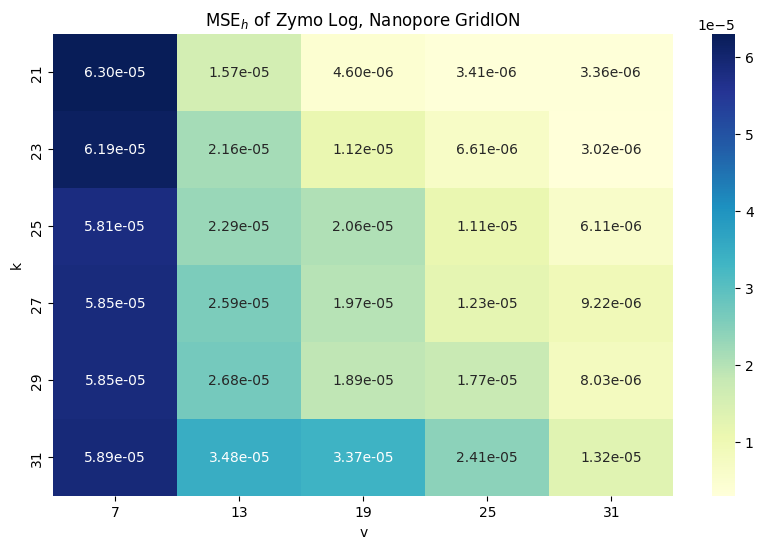

<Figure size 640x480 with 0 Axes>

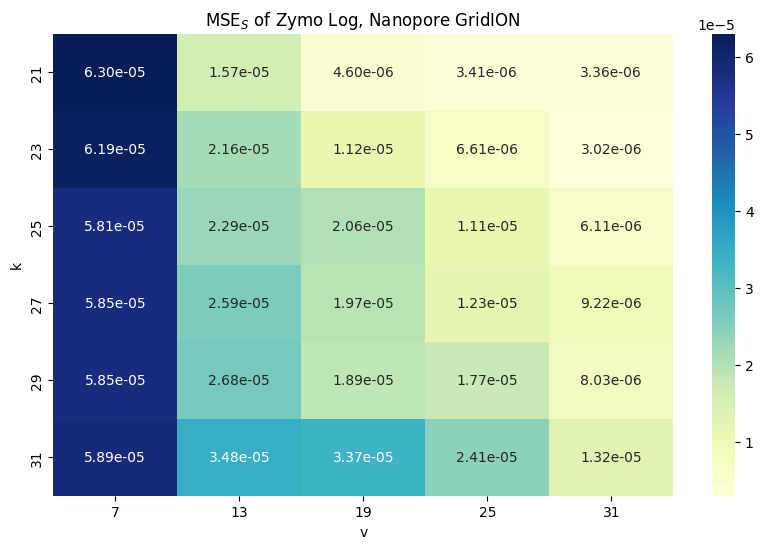

<Figure size 640x480 with 0 Axes>

In [21]:
import pandas as pd

k_range = [21, 23, 25, 27, 29, 31]
v_range = [7, 13, 19, 25, 31]


ground_truth_survival_rate_file = "../../output/zymo/ERR3152366.kmer_match.csv"
ground_truth_survival_rate_df = pd.read_csv(ground_truth_survival_rate_file)
ground_truth_survival_rate = list(ground_truth_survival_rate_df["num_matched_kmers"])

k_list = []
v_list = []
hazard_rate_mse_list = []
survival_rate_mse_list = []

for k in k_range:
    for v in v_range:
        survival_rate_file = f"../../output/parameter_dependence/ERR3152366_k{k}_v{v}.csv"
        survival_rate_df = pd.read_csv(survival_rate_file)
        est_lambda = survival_rate_df["lambda"].item()
        est_beta = survival_rate_df["beta"].item()

        hazard_rate_mse = find_hazard_rate_mise_weibull(ground_truth_survival_rate, est_lambda, est_beta)
        survival_rate_mse = find_survival_rate_mise_weibull(ground_truth_survival_rate, est_lambda, est_beta)

        # Record the results
        k_list.append(k)
        v_list.append(v)
        hazard_rate_mse_list.append(hazard_rate_mse)
        survival_rate_mse_list.append(survival_rate_mse)

results_df = pd.DataFrame({
    "k": k_list,
    "v": v_list,
    "hazard_rate_mse": hazard_rate_mse_list,
    "survival_rate_mse": survival_rate_mse_list
})

# Plot hazard_rate_mse as a heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

hazard_rate_mse_pivot = results_df.pivot(index="k", columns="v", values="hazard_rate_mse")
sns.heatmap(hazard_rate_mse_pivot, annot=True, fmt=".2e", cmap="YlGnBu")

plt.title("MSE$_h$ of Zymo Log, Nanopore GridION")
plt.xlabel("v")
plt.ylabel("k")
plt.show()
plt.savefig("../../output/parameter_dependence/ERR3152366_param_dependence_hazard_rate.pdf")


plt.figure(figsize=(10, 6))

survival_rate_mse_pivot = results_df.pivot(index="k", columns="v", values="survival_rate_mse")
sns.heatmap(hazard_rate_mse_pivot, annot=True, fmt=".2e", cmap="YlGnBu")

plt.title("MSE$_S$ of Zymo Log, Nanopore GridION")
plt.xlabel("v")
plt.ylabel("k")
plt.show()
plt.savefig("../../output/parameter_dependence/ERR3152366_param_dependence_survival_rate.pdf")
